In [24]:
df['good_conditions'] = (
    (df['temp'] > 0.4) &
    (df['hum'] < 0.7) &
    (df['weathersit'] == 1)
).astype(int)

In [25]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,temp_hum,bad_weather,is_year_start,is_year_end,cnt_lag_1,cnt_lag_7,cnt_roll_3,cnt_roll_7,weekend_not_holiday,good_conditions
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.1944,0,1,0,NaN,NaN,NaN,NaN,1,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.1760,0,1,0,16.0,NaN,NaN,NaN,1,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.1760,0,1,0,40.0,NaN,29.333333,NaN,1,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.1800,0,1,0,32.0,NaN,28.333333,NaN,1,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.1800,0,1,0,13.0,NaN,15.333333,NaN,1,0


In [26]:
df.drop(['instant'], axis=1, inplace=True)

In [27]:
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,...,temp_hum,bad_weather,is_year_start,is_year_end,cnt_lag_1,cnt_lag_7,cnt_roll_3,cnt_roll_7,weekend_not_holiday,good_conditions
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,...,0.1944,0,1,0,NaN,NaN,NaN,NaN,1,0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,...,0.1760,0,1,0,16.0,NaN,NaN,NaN,1,0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,...,0.1760,0,1,0,40.0,NaN,29.333333,NaN,1,0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,...,0.1800,0,1,0,32.0,NaN,28.333333,NaN,1,0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,...,0.1800,0,1,0,13.0,NaN,15.333333,NaN,1,0


In [30]:
pd.set_option('display.max_columns', None)
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,is_weekend,is_peak_hour,is_night,temp_hum,bad_weather,is_year_start,is_year_end,cnt_lag_1,cnt_lag_7,cnt_roll_3,cnt_roll_7,weekend_not_holiday,good_conditions
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16,1,0,1,0.1944,0,1,0,NaN,NaN,NaN,NaN,1,0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40,1,0,1,0.1760,0,1,0,16.0,NaN,NaN,NaN,1,0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32,1,0,1,0.1760,0,1,0,40.0,NaN,29.333333,NaN,1,0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13,1,0,1,0.1800,0,1,0,32.0,NaN,28.333333,NaN,1,0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1,1,0,1,0.1800,0,1,0,13.0,NaN,15.333333,NaN,1,0


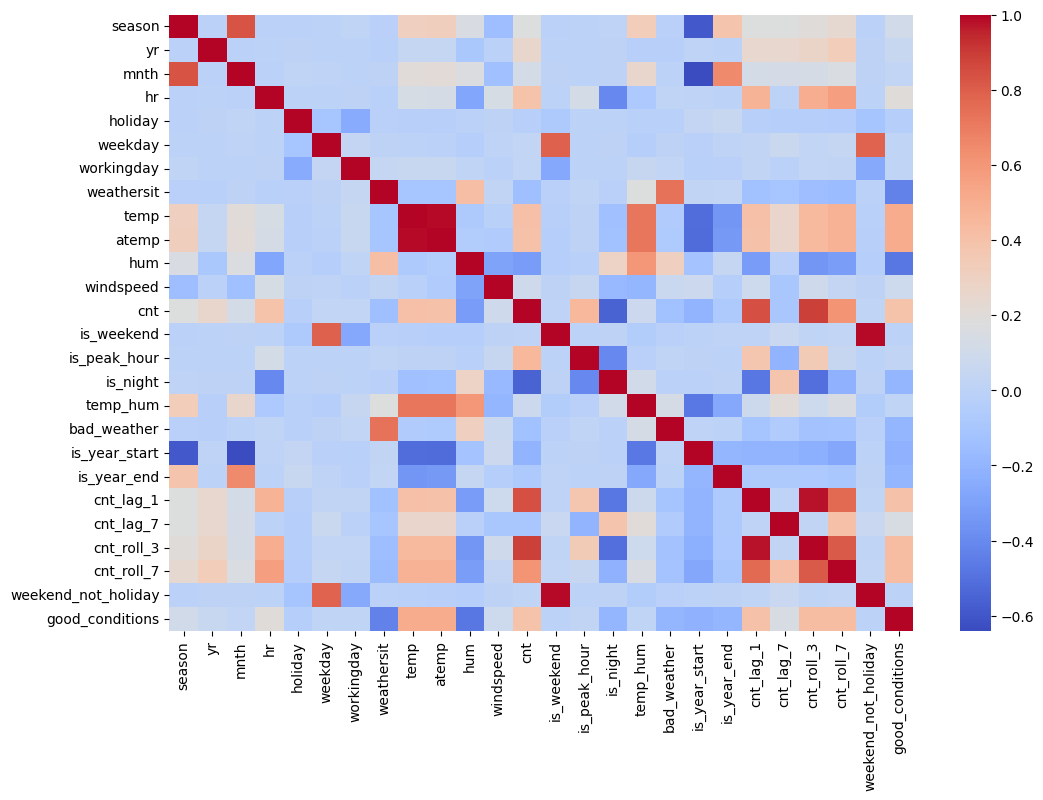

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=False,
            cmap='coolwarm')
plt.show()

In [37]:
from sklearn.feature_selection import VarianceThreshold
X_full = df.drop('cnt', axis=1)
X_numeric = X_full.select_dtypes(include='number')
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_numeric)
low_variance_features = X_numeric.columns[~selector.get_support()]
print("Low variance numeric features:")
print(low_variance_features)

Low variance numeric features:
Index([], dtype='object')


In [38]:
    X_numeric.var().sort_values().head(10)

windspeed              0.014967
temp_hum               0.021043
holiday                0.027944
temp                   0.037078
hum                    0.037222
bad_weather            0.075132
is_year_start          0.133991
is_year_end            0.139797
is_peak_hour           0.188149
weekend_not_holiday    0.203737
dtype: float64

In [43]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [44]:
df.tail()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,is_weekend,is_peak_hour,is_night,temp_hum,bad_weather,is_year_start,is_year_end,cnt_lag_1,cnt_lag_7,cnt_roll_3,cnt_roll_7,weekend_not_holiday,good_conditions
17374,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.60,0.1642,119,0,1,0,0.1560,0,0,1,122.0,224.0,135.000000,197.714286,0,0
17375,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.60,0.1642,89,0,0,0,0.1560,0,0,1,119.0,203.0,110.000000,181.428571,0,0
17376,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.60,0.1642,90,0,0,0,0.1560,0,0,1,89.0,247.0,99.333333,159.000000,0,0
17377,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.56,0.1343,61,0,0,1,0.1456,0,0,1,90.0,315.0,80.000000,122.714286,0,0
17378,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.65,0.1343,49,0,0,1,0.1690,0,0,1,61.0,214.0,66.666667,99.142857,0,0


In [3]:
import pandas as pd

df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['day_of_week'] = df['dteday'].dt.weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [5]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,hum,windspeed,casual,registered,cnt,day,month,year,day_of_week,is_weekend
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.81,0.0,3,13,16,1,1,2011,5,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.80,0.0,8,32,40,1,1,2011,5,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.80,0.0,5,27,32,1,1,2011,5,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.75,0.0,3,10,13,1,1,2011,5,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.75,0.0,0,1,1,1,1,2011,5,1


In [8]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'day', 'month', 'year', 'day_of_week',
       'is_weekend'],
      dtype='object')

In [9]:
df['temp_hum'] = df['temp'] * df['hum']

In [10]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,windspeed,casual,registered,cnt,day,month,year,day_of_week,is_weekend,temp_hum
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.0,3,13,16,1,1,2011,5,1,0.1944
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.0,8,32,40,1,1,2011,5,1,0.1760
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.0,5,27,32,1,1,2011,5,1,0.1760
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.0,3,10,13,1,1,2011,5,1,0.1800
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.0,0,1,1,1,1,2011,5,1,0.1800


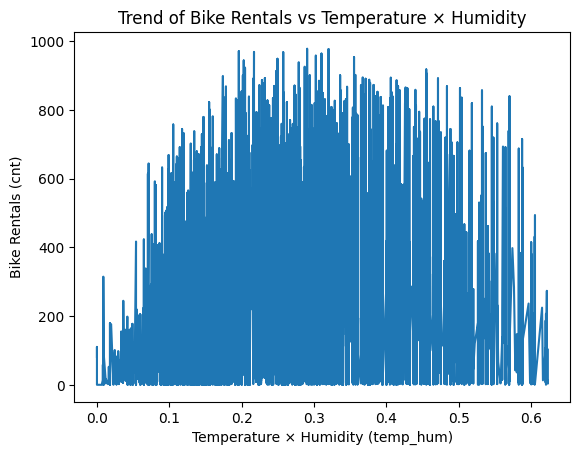

In [12]:
import matplotlib.pyplot as plt

# Sort values for smooth line
df_sorted = df.sort_values('temp_hum')

plt.figure()
plt.plot(df_sorted['temp_hum'], df_sorted['cnt'])
plt.xlabel('Temperature × Humidity (temp_hum)')
plt.ylabel('Bike Rentals (cnt)')
plt.title('Trend of Bike Rentals vs Temperature × Humidity')
plt.show()

In [14]:
df['casual_ratio'] = df['casual'] / (df['cnt'] + 1)
df['registered_ratio'] = df['registered'] / (df['cnt'] + 1)

In [15]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,registered,cnt,day,month,year,day_of_week,is_weekend,temp_hum,casual_ratio,registered_ratio
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,13,16,1,1,2011,5,1,0.1944,0.176471,0.764706
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,32,40,1,1,2011,5,1,0.1760,0.195122,0.780488
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,27,32,1,1,2011,5,1,0.1760,0.151515,0.818182
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,10,13,1,1,2011,5,1,0.1800,0.214286,0.714286
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,1,1,1,2011,5,1,0.1800,0.000000,0.500000


In [17]:
import numpy as np

In [18]:
df['mnth_sin'] = np.sin(2 * np.pi * df['mnth'] / 12)
df['mnth_cos'] = np.cos(2 * np.pi * df['mnth'] / 12)

In [19]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,day,month,year,day_of_week,is_weekend,temp_hum,casual_ratio,registered_ratio,mnth_sin,mnth_cos
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,1,1,2011,5,1,0.1944,0.176471,0.764706,0.5,0.866025
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,1,1,2011,5,1,0.1760,0.195122,0.780488,0.5,0.866025
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,1,1,2011,5,1,0.1760,0.151515,0.818182,0.5,0.866025
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,1,1,2011,5,1,0.1800,0.214286,0.714286,0.5,0.866025
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,1,1,2011,5,1,0.1800,0.000000,0.500000,0.5,0.866025


In [2]:
import pandas as pd

df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df['high_humidity'] = df['hum'].apply(lambda x: 1 if x > 0.7 else 0)


In [4]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,high_humidity
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,1


In [5]:
df['windy'] = df['windspeed'].apply(lambda x: 1 if x > 0.4 else 0)

In [6]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,high_humidity,windy
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,1,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,1,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,1,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,1,0


In [9]:
df['cnt_momentum'] = df['cnt'].shift(1) - df['cnt'].shift(7)

In [10]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,high_humidity,windy,cnt_momentum
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,1,0,NaN
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1,0,NaN
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,1,0,NaN
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,1,0,NaN
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,1,0,NaN


In [2]:
import pandas as pd

df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [5]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['day_of_week'] = df['dteday'].dt.weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [6]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,hum,windspeed,casual,registered,cnt,day,month,year,day_of_week,is_weekend
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.81,0.0,3,13,16,1,1,2011,5,1
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.80,0.0,8,32,40,1,1,2011,5,1
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.80,0.0,5,27,32,1,1,2011,5,1
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.75,0.0,3,10,13,1,1,2011,5,1
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.75,0.0,0,1,1,1,1,2011,5,1


In [7]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'day', 'month', 'year', 'day_of_week',
       'is_weekend'],
      dtype='object')

In [8]:
df['is_year_start'] = df['mnth'].apply(lambda x: 1 if x <= 2 else 0)
df['is_year_end'] = df['mnth'].apply(lambda x: 1 if x >= 11 else 0)

In [9]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,casual,registered,cnt,day,month,year,day_of_week,is_weekend,is_year_start,is_year_end
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,3,13,16,1,1,2011,5,1,1,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,8,32,40,1,1,2011,5,1,1,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,5,27,32,1,1,2011,5,1,1,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,3,10,13,1,1,2011,5,1,1,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0,1,1,1,1,2011,5,1,1,0


In [10]:
df['is_peak_hour'] = df['hr'].apply(
    lambda x: 1 if x in [7,8,9,17,18,19] else 0
)

In [11]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'day', 'month', 'year', 'day_of_week',
       'is_weekend', 'is_year_start', 'is_year_end', 'is_peak_hour'],
      dtype='object')

In [12]:
df['high_humidity'] = df['hum'].apply(lambda x: 1 if x > 0.7 else 0)


In [13]:
df['windy'] = df['windspeed'].apply(lambda x: 1 if x > 0.4 else 0)

In [14]:
df['cnt_momentum'] = df['cnt'].shift(1) - df['cnt'].shift(7)

In [15]:
df['temp_hum'] = df['temp'] * df['hum']

In [16]:
df['is_night'] = df['hr'].apply(lambda x: 1 if x <= 5 or x >= 22 else 0)

In [17]:
df['bad_weather'] = df['weathersit'].apply(lambda x: 1 if x >= 3 else 0)

In [18]:
df['cnt_lag_1'] = df['cnt'].shift(1)
df['cnt_lag_7'] = df['cnt'].shift(7)

In [19]:
df[['cnt', 'cnt_lag_1', 'cnt_lag_7']].tail(10)

,cnt,cnt_lag_1,cnt_lag_7
17369,247,203.0,85.0
17370,315,247.0,196.0
17371,214,315.0,157.0
17372,164,214.0,120.0
17373,122,164.0,157.0
17374,119,122.0,224.0
17375,89,119.0,203.0
17376,90,89.0,247.0
17377,61,90.0,315.0
17378,49,61.0,214.0


In [20]:
df['cnt_roll_3'] = df['cnt'].rolling(window=3).mean()
df['cnt_roll_7'] = df['cnt'].rolling(window=7).mean()

In [21]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'day', 'month', 'year', 'day_of_week',
       'is_weekend', 'is_year_start', 'is_year_end', 'is_peak_hour',
       'high_humidity', 'windy', 'cnt_momentum', 'temp_hum', 'is_night',
       'bad_weather', 'cnt_lag_1', 'cnt_lag_7', 'cnt_roll_3', 'cnt_roll_7'],
      dtype='object')

In [23]:
X = df.drop('cnt', axis=1)
y = df['cnt']

In [28]:
X.dtypes

instant                   int64
dteday           datetime64[ns]
season                    int64
yr                        int64
mnth                      int64
hr                        int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit                int64
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
day                       int32
month                     int32
year                      int32
day_of_week               int32
is_weekend                int64
is_year_start             int64
is_year_end               int64
is_peak_hour              int64
high_humidity             int64
windy                     int64
cnt_momentum            float64
temp_hum                float64
is_night                  int64
bad_weather               int64
cnt_lag_1               float64
cnt_lag_

In [29]:
X = X.drop(columns=['dteday'], errors='ignore')

In [30]:
X = pd.get_dummies(X, drop_first=True)


In [31]:
y = df['cnt'].astype(int)

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


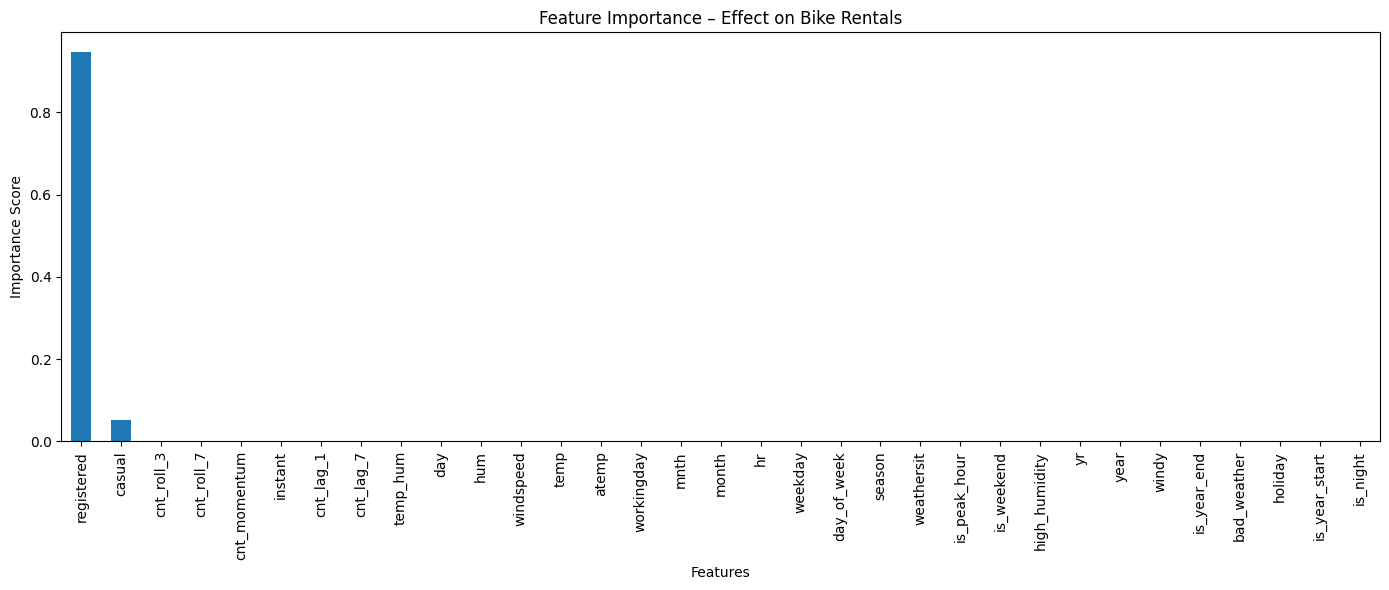

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance series
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot ALL features
plt.figure(figsize=(14,6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance – Effect on Bike Rentals')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [35]:
X = df.drop(['cnt', 'casual', 'registered', 'dteday'], axis=1)
y = df['cnt']

In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X, y)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


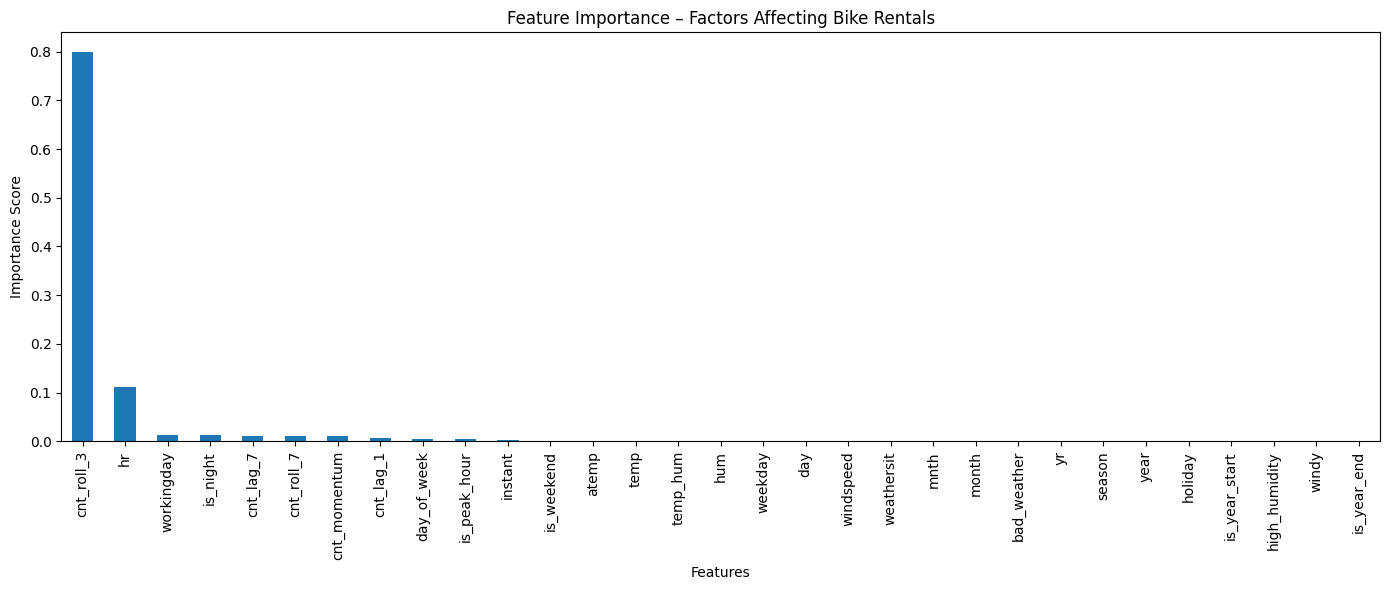

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
importance.plot(kind='bar')
plt.title('Feature Importance – Factors Affecting Bike Rentals')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd

df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df['good_conditions'] = (
    (df['temp'] > 0.4) &
    (df['hum'] < 0.7) &
    (df['weathersit'] == 1)
).astype(int)

In [4]:
df['temp_hum'] = df['temp'] * df['hum']

In [5]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year
df['day_of_week'] = df['dteday'].dt.weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [6]:
df['is_year_start'] = df['mnth'].apply(lambda x: 1 if x <= 2 else 0)
df['is_year_end'] = df['mnth'].apply(lambda x: 1 if x >= 11 else 0)

In [7]:
df['high_humidity'] = df['hum'].apply(lambda x: 1 if x > 0.7 else 0)

In [8]:
df['is_night'] = df['hr'].apply(lambda x: 1 if x <= 5 or x >= 22 else 0)

In [9]:
df['bad_weather'] = df['weathersit'].apply(lambda x: 1 if x >= 3 else 0)

In [10]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'good_conditions', 'temp_hum', 'day',
       'month', 'year', 'day_of_week', 'is_weekend', 'is_year_start',
       'is_year_end', 'high_humidity', 'is_night', 'bad_weather'],
      dtype='object')

In [13]:
df['is_peak_hour'] = df['hr'].apply(
    lambda x: 1 if x in [7,8,9,17,18,19] else 0
)

In [14]:

df['is_morning_peak'] = df['hr'].between(7,9).astype(int)
df['is_evening_peak'] = df['hr'].between(17,19).astype(int)


In [15]:
import numpy as np

df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)

df['month_sin'] = np.sin(2*np.pi*df['mnth']/12)
df['month_cos'] = np.cos(2*np.pi*df['mnth']/12)


In [16]:
df['cnt_lag_1'] = df['cnt'].shift(1)
df['cnt_lag_24'] = df['cnt'].shift(24)
df['cnt_lag_168'] = df['cnt'].shift(168)


In [17]:
df['cnt_roll_3'] = df['cnt'].rolling(3).mean()
df['cnt_roll_24'] = df['cnt'].rolling(24).mean()


In [18]:
df['temp_squared'] = df['temp'] ** 2
df['temp_humidity'] = df['temp'] * df['hum']
df['bad_weather'] = (df['weathersit'] >= 3).astype(int)


In [19]:
df['workingday_hr'] = df['workingday'] * df['hr']
df['holiday_hr'] = df['holiday'] * df['hr']


df.columns

In [31]:
df['cnt_roll_168'] = df['cnt'].rolling(168).mean()
df['cnt_diff_1'] = df['cnt'] - df['cnt_lag_1']
df['temp_windspeed'] = df['temp'] * df['windspeed']


In [32]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'good_conditions', 'temp_hum', 'day',
       'month', 'year', 'day_of_week', 'is_weekend', 'is_year_start',
       'is_year_end', 'high_humidity', 'is_night', 'bad_weather',
       'is_peak_hour', 'is_morning_peak', 'is_evening_peak', 'hr_sin',
       'hr_cos', 'month_sin', 'month_cos', 'cnt_lag_1', 'cnt_lag_24',
       'cnt_lag_168', 'cnt_roll_3', 'cnt_roll_24', 'temp_squared',
       'temp_humidity', 'workingday_hr', 'holiday_hr', 'cnt_roll_168',
       'cnt_diff_1', 'temp_windspeed'],
      dtype='object')

In [33]:
df.shape

(17379, 48)

In [42]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt', 'good_conditions', 'temp_hum', 'day',
       'month', 'year', 'day_of_week', 'is_weekend', 'is_year_start',
       'is_year_end', 'high_humidity', 'is_night', 'bad_weather',
       'is_peak_hour', 'is_morning_peak', 'is_evening_peak', 'hr_sin',
       'hr_cos', 'month_sin', 'month_cos', 'cnt_lag_1', 'cnt_lag_24',
       'cnt_lag_168', 'cnt_roll_3', 'cnt_roll_24', 'temp_squared',
       'temp_humidity', 'workingday_hr', 'holiday_hr', 'cnt_roll_168',
       'cnt_diff_1', 'temp_windspeed'],
      dtype='object')

In [46]:
df_work = df.copy()

df_work = df_work.drop(columns=[
    'instant',
    'dteday',
    'casual',
    'registered',
    'mnth',
    'yr',
    'weekday'
])

df_work = df_work.dropna().reset_index(drop=True)

X = df_work.drop('cnt', axis=1)
y = df_work['cnt']

print(X.columns)
print("Total features:", X.shape[1])


Index(['season', 'hr', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp',
       'hum', 'windspeed', 'good_conditions', 'temp_hum', 'day', 'month',
       'year', 'day_of_week', 'is_weekend', 'is_year_start', 'is_year_end',
       'high_humidity', 'is_night', 'bad_weather', 'is_peak_hour',
       'is_morning_peak', 'is_evening_peak', 'hr_sin', 'hr_cos', 'month_sin',
       'month_cos', 'cnt_lag_1', 'cnt_lag_24', 'cnt_lag_168', 'cnt_roll_3',
       'cnt_roll_24', 'temp_squared', 'temp_humidity', 'workingday_hr',
       'holiday_hr', 'cnt_roll_168', 'cnt_diff_1', 'temp_windspeed'],
      dtype='object')
Total features: 40


In [47]:
{'instant','dteday','casual','registered'}.intersection(X.columns)


set()

In [48]:
X = df_clean[
    ['season', 'hr', 'holiday', 'workingday', 'weathersit', 'temp', 'atemp',
     'hum', 'windspeed', 'good_conditions', 'temp_hum', 'day', 'month',
     'year', 'day_of_week', 'is_weekend', 'is_year_start', 'is_year_end',
     'high_humidity', 'is_night', 'bad_weather', 'is_peak_hour',
     'is_morning_peak', 'is_evening_peak', 'hr_sin', 'hr_cos', 'month_sin',
     'month_cos', 'cnt_lag_1', 'cnt_lag_24', 'cnt_lag_168', 'cnt_roll_3',
     'cnt_roll_24', 'temp_squared', 'temp_humidity', 'workingday_hr',
     'holiday_hr', 'cnt_roll_168', 'cnt_diff_1', 'temp_windspeed']
]

y = df_clean['cnt']


In [49]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


In [50]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print(f"Linear Regression Evaluation")
print(f"R²   : {lr_r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


Linear Regression Evaluation
R²   : 1.0000
MAE  : 0.00
RMSE : 0.00


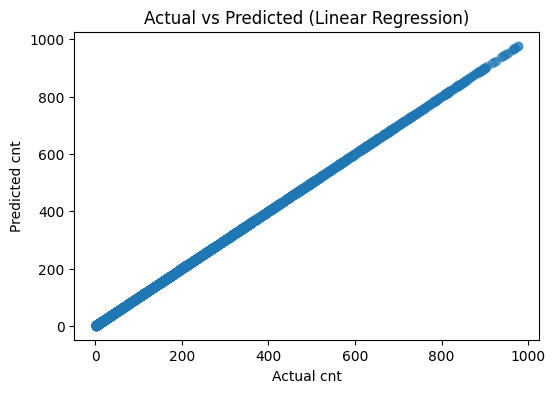

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


In [53]:
comparison = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted': lr_pred[:10]
})

comparison


,Actual,Predicted
0,381,381.0
1,233,233.0
2,136,136.0
3,67,67.0
4,28,28.0
5,14,14.0
6,6,6.0
7,10,10.0
8,41,41.0
9,167,167.0


In [54]:
y_test_pred = lr.predict(X_test)


In [55]:
new_sample = X_test.iloc[[0]]   # double brackets are IMPORTANT
prediction = lr.predict(new_sample)

print("Predicted bike count:", int(prediction[0]))


Predicted bike count: 380


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)


In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Evaluation")
print(f"R²   : {rf_r2:.4f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")


Random Forest Evaluation
R²   : 0.9890
MAE  : 10.09
RMSE : 23.07


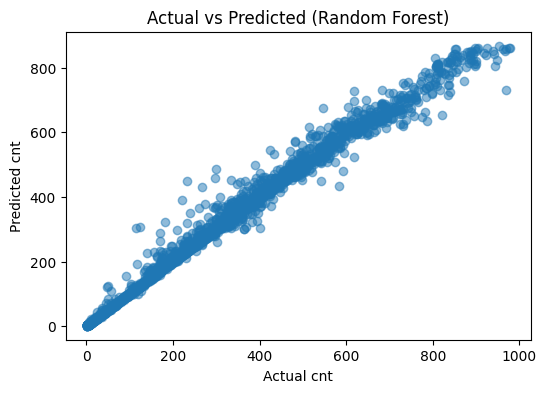

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()


In [59]:
comparison_rf = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted_RF': rf_pred[:10]
})

comparison_rf


,Actual,Predicted_RF
0,381,369.324978
1,233,237.633464
2,136,137.575452
3,67,67.283583
4,28,27.470317
5,14,14.270772
6,6,6.021598
7,10,9.843000
8,41,40.500684
9,167,167.220231


In [60]:
sample = X_test.iloc[[0]]
prediction = rf.predict(sample)

print("Predicted bike count:", int(prediction[0]))


Predicted bike count: 369


In [61]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [lr_r2, rf_r2]
})

results


,Model,R2
0,Linear Regression,1.000000
1,Random Forest,0.988982


In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)
gbr_r2 = r2_score(y_test, gbr_pred)


In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("Gradient Boosting Evaluation")
print(f"R²   : {gbr_r2:.4f}")
print(f"MAE  : {gbr_mae:.2f}")
print(f"RMSE : {gbr_rmse:.2f}")


Gradient Boosting Evaluation
R²   : 0.9947
MAE  : 9.91
RMSE : 16.04


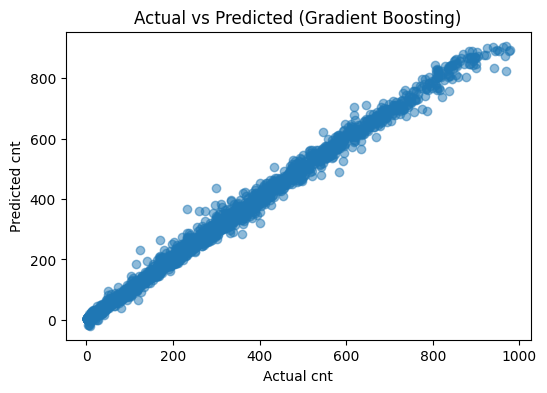

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, gbr_pred, alpha=0.5)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()


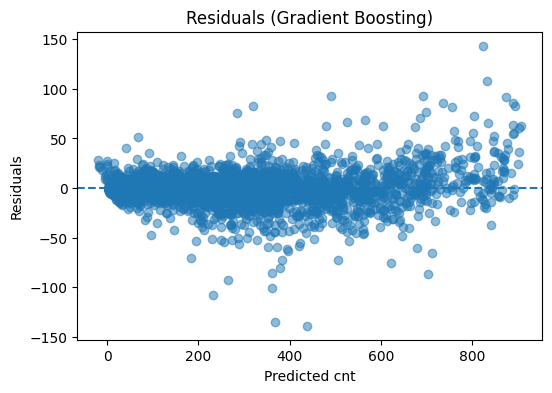

In [65]:
residuals = y_test - gbr_pred

plt.figure(figsize=(6,4))
plt.scatter(gbr_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted cnt")
plt.ylabel("Residuals")
plt.title("Residuals (Gradient Boosting)")
plt.show()


In [66]:
comparison_gbr = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted_GBR': gbr_pred[:10]
})

comparison_gbr


,Actual,Predicted_GBR
0,381,363.106274
1,233,223.758641
2,136,150.295467
3,67,69.098390
4,28,32.034839
5,14,12.904188
6,6,7.229480
7,10,9.292767
8,41,36.580721
9,167,165.342297


In [67]:
sample = X_test.iloc[[0]]
prediction = gbr.predict(sample)

print("Predicted bike count:", int(prediction[0]))


Predicted bike count: 363


In [68]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        gbr_r2
    ]
})

results.sort_values(by='R2 Score', ascending=False)


,Model,R2 Score
0,Linear Regression,1.000000
2,Gradient Boosting,0.994675
1,Random Forest,0.988982


In [69]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_r2 = r2_score(y_test, xgb_pred)


In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost Evaluation")
print(f"R²   : {xgb_r2:.4f}")
print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")


XGBoost Evaluation
R²   : 0.9944
MAE  : 8.31
RMSE : 16.52


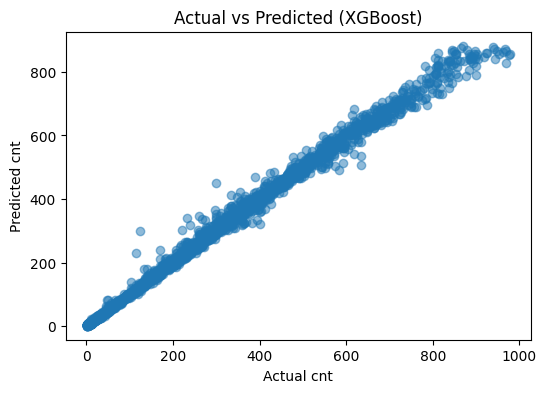

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()


In [72]:
comparison_xgb = pd.DataFrame({
    'Actual': y_test[:10].values,
    'Predicted_XGB': xgb_pred[:10]
})

comparison_xgb


,Actual,Predicted_XGB
0,381,380.313354
1,233,230.567535
2,136,149.813568
3,67,65.554817
4,28,25.370615
5,14,14.797176
6,6,5.685623
7,10,9.232121
8,41,38.911274
9,167,166.158875


In [73]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],
    'R2 Score': [
        lr_r2,
        rf_r2,
        gbr_r2,
        xgb_r2
    ],
    'MAE': [
        mae,
        rf_mae,
        gbr_mae,
        xgb_mae
    ],
    'RMSE': [
        rmse,
        rf_rmse,
        gbr_rmse,
        xgb_rmse
    ]
})

results.sort_values(by='R2 Score', ascending=False)


,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.000000,3.022031e-13,4.036767e-13
2,Gradient Boosting,0.994675,9.907172e+00,1.604145e+01
3,XGBoost,0.994352,8.307910e+00,1.652026e+01
1,Random Forest,0.988982,1.008654e+01,2.307476e+01


In [74]:
best_model_name = results.loc[results['R2 Score'].idxmax(), 'Model']
print("Best Model:", best_model_name)


Best Model: Linear Regression


In [75]:
final_prediction = xgb.predict(X_test.iloc[[0]])
print("Predicted bike count:", int(final_prediction[0]))


Predicted bike count: 380


In [76]:
y_test_final_pred = xgb.predict(X_test)


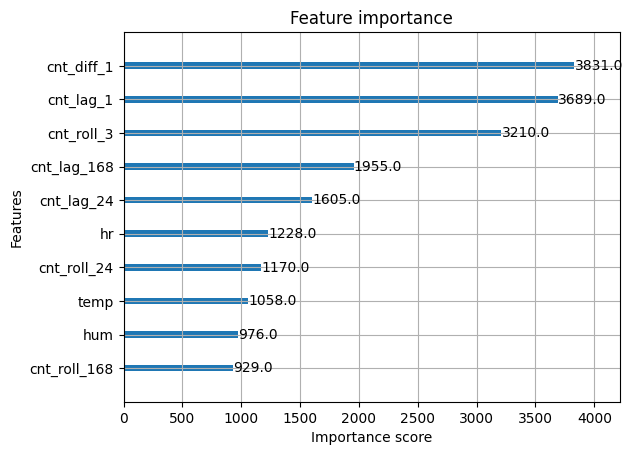

In [78]:
import xgboost as xgb_module
import matplotlib.pyplot as plt

xgb_module.plot_importance(xgb, max_num_features=10)
plt.show()


In [79]:
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [80]:
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013793 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3035
[LightGBM] [Info] Number of data points in the train set: 13768, number of used features: 40
[LightGBM] [Info] Start training from score 176.516124
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [81]:
lgbm_pred = lgbm.predict(X_test)


In [82]:
lgbm_r2 = r2_score(y_test, lgbm_pred)
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

print("LightGBM Evaluation")
print(f"R²   : {lgbm_r2:.4f}")
print(f"MAE  : {lgbm_mae:.2f}")
print(f"RMSE : {lgbm_rmse:.2f}")


LightGBM Evaluation
R²   : 0.9949
MAE  : 8.57
RMSE : 15.71


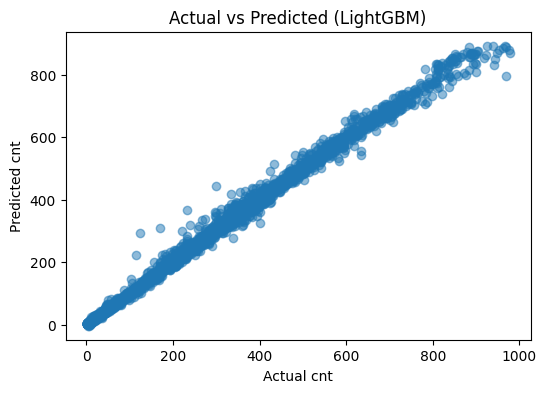

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, lgbm_pred, alpha=0.5)
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title("Actual vs Predicted (LightGBM)")
plt.show()


In [84]:
sample = X_test.iloc[[0]]
prediction = lgbm.predict(sample)

print("Predicted bike count:", int(prediction[0]))


Predicted bike count: 360
